In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import textwrap

import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(parent_dir)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
d = {'עמודה1': 'model', 'Unnamed: 0': 'model'}
df_all = pd.read_excel("../PPRs.xlsx", sheet_name='PPRs all').rename(columns=d).set_index('model')
df_inner = pd.read_excel("../PPRs.xlsx", sheet_name='PPRs inner').rename(columns=d).set_index('model')
df_sppr_not_explode = pd.read_excel("../PPRs.xlsx", sheet_name='SPPR did not explode').rename(columns=d).set_index('model')
df_outflow_minus_inflow = pd.read_excel("../PPRs.xlsx", sheet_name='outflow minus inflow').rename(columns=d).set_index('model')

check_cols = ['model is balanced', 'DC rows sum to 1', 'catch is not negative']
df_checks = df_all[check_cols].copy()
df_all = df_all.drop(columns=check_cols + ['model is fine'])
df_inner = df_inner.drop(columns=check_cols + ['model is fine'])

renaming_dict = {
    'SPPR_1995_mTL_global_TE_01': '1995 with TE=0.1',
    'SPPR_1995_mTL_global_mTE': '1995 with global mean TE',
    'SPPR_1995_TL_Jensened_global_mTE': '1995 with TL Jensened and global mean TE',
    'SPPR_1995_TL_TE_Jensened': '1995 with TL Jensened and TE Jensened',
    'SPPR_EwE': 'EwE for Harvest',
    'SPPR_2015': '2015',
    'SPPR_new_GE': 'new using GE',
    'SPPR_new_full': 'new using full flow',
    'SPPR_symbolic_GE_import_as_DC': 'new using GE and diet_import sppr distributes as DC',
    # 'SPPR_symbolic_full_import_as_DC': 'new using full flow and diet_import sppr distributes as DC',
    'SPPR_mc_GE_10_20': 'new with GE and monte-carlo on TE',
    # 'SPPR_mc_full_10_20': 'new with full flow and monte-carlo on TE'
}
sppr_cols = list(renaming_dict.keys())
df_all = df_all[sppr_cols]
df_inner = df_inner[sppr_cols]
df_sppr_not_explode = df_sppr_not_explode[sppr_cols]
df_outflow_minus_inflow = df_outflow_minus_inflow[sppr_cols]

In [5]:
df_all

,SPPR_1995_mTL_global_TE_01,SPPR_1995_mTL_global_mTE,SPPR_1995_TL_Jensened_global_mTE,SPPR_1995_TL_TE_Jensened,SPPR_EwE,SPPR_2015,SPPR_new_GE,SPPR_new_full,SPPR_symbolic_GE_import_as_DC,SPPR_mc_GE_10_20
model,,,,,,,,,,
"[2] Alaska, Prince William Sound 1980",2369.431820,31.770929,34.683529,734.106833,697.500489,971.166250,3464.950723,1982.383033,3464.950723,7122.907177
[7] Azores archipelago 1997,19.784511,15.200121,84.827758,180.499294,62.329990,388.093349,35.648287,8.314041,-25937.933387,39.263447
[28] Central Atlantic 1950,1.050083,0.124892,0.253673,86.537946,24.818295,2950.078195,42.888812,10.700865,42.888812,66.042956
[29] Central Atlantic 1990,21.681885,19.633470,86.711001,582.685717,410.044212,2947.368640,369.043441,110.806469,369.043441,612.649939
[40] Eastern Scotian Shelf 1980,485.826137,236.953246,698.282712,1557.592875,1167.706509,1783.278819,427.614322,203.497371,525.310385,457.012794
...,...,...,...,...,...,...,...,...,...,...
[691] Black Sea 1960,4.587198,3.221360,6.040274,155.843795,74.262190,135.809348,12.001304,6.399665,15.381194,12.604398
[692] Black Sea 1980,48.290574,116.581657,188.416173,155.058658,75.119585,158.706912,46.027401,27.792365,52.924708,49.017116
[693] Black Sea 1988,22.995681,17.509544,26.644019,45.286345,25.500592,44.723589,22.464431,12.952157,26.328275,23.102928


In [6]:
from scipy.stats import gmean as gmean_func

def calculate_gsd(data):
    """Calculates the Geometric Standard Deviation."""
    log_data = np.log(data)
    # ddof=1 for sample GSD
    return np.exp(np.std(log_data, ddof=1))

def calc_mean_ratio(base_method, target_method, percentile):
    if target_method == base_method:
        good_models = df_checks.all(axis=1) & df_sppr_not_explode[target_method]
        s = pd.Series(1.0, index=df_all.index)
        return 1.0, 1.0, s[good_models]

    df = df_all[[base_method, target_method]]
    df = df.mul(1/df[base_method], axis='index')
    good_models = df_checks.all(axis=1) & df_sppr_not_explode[target_method]
    s = df.loc[good_models, target_method]
    f = (s < np.percentile(s, percentile)) & (s > 0)
    mean = gmean_func(s[f])
    gsd = calculate_gsd(s[f])
    return mean, gsd, s[f]

def get_ratio_df(base_method, percentile):
    results = dict()
    for target_method in df_all.columns:
        mean, gsd, _ = calc_mean_ratio(base_method, target_method, percentile)
        results[f'{renaming_dict[target_method]}'] = mean, gsd

    return pd.DataFrame(results, index=['Geometric Mean', 'Geometric Standard Deviation'])

def plot_ratio_bars(results, plot_errors=True, figure_size=(13, 6), label_width=18, title=None):
    gmean = results.loc['Geometric Mean']
    gsd = results.loc['Geometric Standard Deviation']

    labels = ["\n".join(textwrap.wrap(str(label), width=label_width)) for label in gmean.index]
    x = np.arange(len(labels))

    y = pd.to_numeric(gmean, errors='coerce').to_numpy()
    lower = pd.to_numeric(gsd, errors='coerce').to_numpy()
    upper = y * lower

    finite = np.isfinite(y)
    finite_y = y[finite]

    if finite_y.size > 0:
        max_display = 1.5 * np.nanmax(finite_y)
    else:
        max_display = 1.5

    if plot_errors:
        lower_bound = np.where((lower > 0) & np.isfinite(y), y / lower, 0)
        visible_lower = np.where(np.isfinite(y), np.maximum(lower_bound, 0), 0)
        visible_upper = np.minimum(upper, max_display)
        yerr = np.vstack([np.where(np.isfinite(y), y - visible_lower, 0),
                          np.where(np.isfinite(y), visible_upper - y, 0)])
    else:
        visible_upper = np.minimum(upper, max_display)
        yerr = None

    fig, ax = plt.subplots(figsize=figure_size)
    bars = ax.bar(x, y, yerr=yerr, capsize=6 if plot_errors else 0,
                  color='tab:blue', alpha=0.9, edgecolor='black', linewidth=0.8)

    for idx, bar in enumerate(bars):
        height = bar.get_height()
        if np.isfinite(height):
            ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=10,
                        color='white', fontweight='bold', bbox=dict(facecolor='black', alpha=0.65, boxstyle='round,pad=0.2'))
        else:
            ax.annotate('n/a', xy=(bar.get_x() + bar.get_width() / 2, 0),
                        xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=10,
                        color='white', fontweight='bold', bbox=dict(facecolor='black', alpha=0.65, boxstyle='round,pad=0.2'))

    if plot_errors:
        clipped = np.isfinite(upper) & (upper > max_display)
        for idx, is_clipped in enumerate(clipped):
            if is_clipped:
                ax.annotate('↑', xy=(x[idx], visible_upper[idx]), xytext=(0, 8), textcoords='offset points',
                            ha='center', color='red', fontsize=14, fontweight='bold')
        # ax.legend([bars.patches[0]], [f'Gmean ± GSD (display capped at {max_display:.2f})'],
        #           loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel('Geometric mean ratio')
    ax.set_title(title)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.set_ylim(bottom=0, top=max_display * 1.08)

    plt.tight_layout()
    plt.show()
    return fig, ax

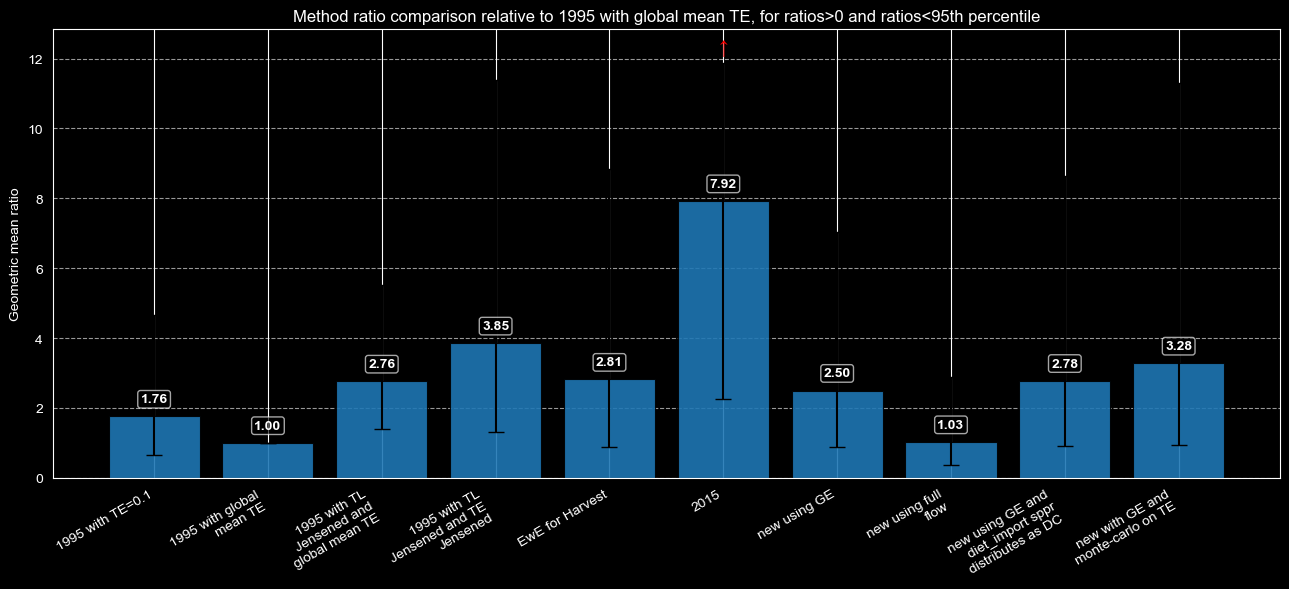

(<Figure size 1300x600 with 1 Axes>,
 <Axes: title={'center': 'Method ratio comparison relative to 1995 with global mean TE, for ratios>0 and ratios<95th percentile'}, ylabel='Geometric mean ratio'>)

In [7]:
base_method = 'SPPR_1995_mTL_global_TE_01'
base_method = 'SPPR_1995_mTL_global_mTE'

percentile = 95

results = get_ratio_df(base_method, percentile)
title = f'Method ratio comparison relative to {renaming_dict[base_method]}, for ratios>0 and ratios<{percentile}th percentile'
plot_ratio_bars(results, plot_errors=True, title=title)

Text(0.5, 1.0, 'histogram for new using full flow relative to 1995 with global mean TE for percentile=100')

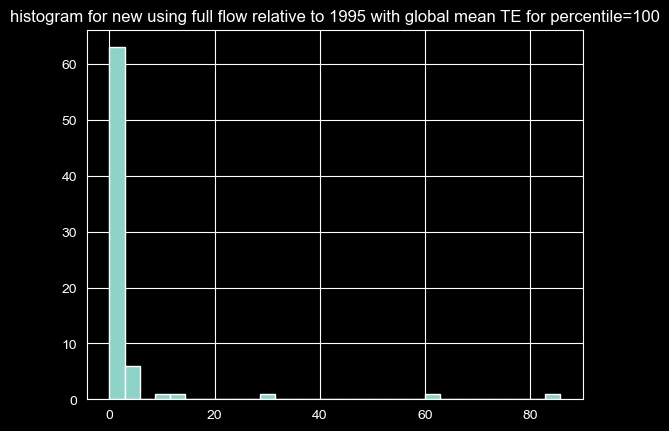

In [8]:
base_method = 'SPPR_1995_mTL_global_mTE'
target_method = 'SPPR_2015'
target_method = 'SPPR_new_full'
percentile=100
m, gsd, s = calc_mean_ratio(base_method, target_method, percentile)
s.hist(bins=30)
plt.title(f'histogram for {renaming_dict[target_method]} relative to {renaming_dict[base_method]} for percentile={percentile}')

## PPR/NPP

In [9]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import textwrap

import os
import sys

# Standard interactive replacement for the 'parent directory' hack
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.append(parent_dir)

from PPRCalculator import PPRCalculator
from utils import species_groups

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [11]:
d = {'עמודה1': 'model', 'Unnamed: 0': 'model'}
df_all = pd.read_excel("../PPRs.xlsx", sheet_name='PPRs all').rename(columns=d).set_index('model')
df_inner = pd.read_excel("../PPRs.xlsx", sheet_name='PPRs inner').rename(columns=d).set_index('model')
df_sppr_not_explode = pd.read_excel("../PPRs.xlsx", sheet_name='SPPR did not explode').rename(columns=d).set_index('model')
df_outflow_minus_inflow = pd.read_excel("../PPRs.xlsx", sheet_name='outflow minus inflow').rename(columns=d).set_index('model')

check_cols = ['model is balanced', 'DC rows sum to 1', 'catch is not negative']
df_checks = df_all[check_cols].copy()
df_all = df_all.drop(columns=check_cols + ['model is fine'])
df_inner = df_inner.drop(columns=check_cols + ['model is fine'])

renaming_dict = {
    'SPPR_1995_mTL_global_TE_01': '1995 with TE=0.1',
    # 'SPPR_1995_mTL_global_mTE': '1995 with global mean TE',
    # 'SPPR_1995_TL_Jensened_global_mTE': '1995 with TL Jensened and global mean TE',
    'SPPR_1995_TL_TE_Jensened': '1995 with TL Jensened and TE Jensened',
    'SPPR_EwE': 'EwE for Harvest',
    'SPPR_2015': '2015',
    'SPPR_new_GE': 'new using GE',
    # 'SPPR_symbolic_GE_import_as_DC': 'new using GE and diet_import sppr distributes as DC',
    'SPPR_mc_GE_10_20': 'new with GE and monte-carlo on TE'
}

renaming_dict = {
    'SPPR_1995_mTL_global_TE_01': '1995 with TE=0.1',
    # 'SPPR_1995_mTL_global_mTE': '1995 with global mean TE',
    # 'SPPR_1995_TL_Jensened_global_mTE': '1995 with TL Jensened and global mean TE',
    'SPPR_1995_TL_TE_Jensened': '1995 with TL Jensened and TE Jensened',
    'SPPR_EwE': 'EwE for Harvest',
    'SPPR_2015': '2015',
    'SPPR_new_GE': 'new using GE',
    'SPPR_new_full': 'new using full flow',
    'SPPR_symbolic_GE_import_as_DC': 'new using GE and diet_import sppr distributes as DC',
    # 'SPPR_symbolic_full_import_as_DC': 'new using full flow and diet_import sppr distributes as DC',
    'SPPR_mc_GE_10_20': 'new with GE and monte-carlo on TE',
    # 'SPPR_mc_full_10_20': 'new with full flow and monte-carlo on TE'
}

sppr_cols = list(renaming_dict.keys())
df_all = df_all[sppr_cols]
df_inner = df_inner[sppr_cols]
df_sppr_not_explode = df_sppr_not_explode[sppr_cols]
df_outflow_minus_inflow = df_outflow_minus_inflow[sppr_cols]

In [12]:
directory = '../real_models'
saved_models = [int(f.split('[')[1].split(']')[0]) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
saved_models.sort()

In [13]:
NPP_all = pd.Series()
NPP_inner = pd.Series()

for model_number in tqdm(saved_models):
    # read model:
    try:
        model = PPRCalculator(model_number)
    except:
        print(f'    model {model_number} failed for unknown reason')
        print('-'*20)
        continue
    
    # don't treat models where catch is 0:
    if model.catch.sum() == 0:
        continue

    year = model.get_model().model_year
    name = model.get_model().model_name
    filename = f'[{model_number}] {name} {year}'

    NPP_all[filename] = model.p[list(model.get_PP_seq()) + list(model.get_Import_seq())].sum()
    NPP_inner[filename] = model.p[model.get_PP_seq()].sum()

100%|██████████| 119/119 [00:10<00:00, 11.37it/s]


In [14]:
PPR2NPP_all = df_all.div(NPP_all, axis='index')
PPR2NPP_inner = df_inner.div(NPP_inner, axis='index')
PPR2NPP_inner

,SPPR_1995_mTL_global_TE_01,SPPR_1995_TL_TE_Jensened,SPPR_EwE,SPPR_2015,SPPR_new_GE,SPPR_new_full,SPPR_symbolic_GE_import_as_DC,SPPR_mc_GE_10_20
model,,,,,,,,
"[2] Alaska, Prince William Sound 1980",0.245609,0.076096,0.072301,0.100669,0.359168,0.205489,0.359168,0.738342
[7] Azores archipelago 1997,0.009669,0.088216,0.030463,0.189675,0.017423,0.004063,-12.486057,0.019189
[28] Central Atlantic 1950,0.000354,0.029194,0.008373,0.995221,0.014469,0.003610,0.014469,0.022280
[29] Central Atlantic 1990,0.007314,0.196571,0.138330,0.994307,0.124498,0.037381,0.124498,0.206680
[40] Eastern Scotian Shelf 1980,0.175019,0.560011,0.419921,0.640866,0.153263,0.072787,0.156008,0.163831
...,...,...,...,...,...,...,...,...
[691] Black Sea 1960,0.017913,0.608418,0.289850,0.530183,0.046720,0.024875,0.046747,0.049075
[692] Black Sea 1980,0.085101,0.273080,0.132211,0.279509,0.080942,0.048842,0.080959,0.086208
[693] Black Sea 1988,0.040525,0.079696,0.044833,0.078704,0.039482,0.022741,0.039488,0.040607


1995 with TE=0.1: 28
1995 with TL Jensened and TE Jensened: 28
EwE for Harvest: 28
2015: 31
new using GE: 29
new using full flow: 32
new using GE and diet_import sppr distributes as DC: 37
new with GE and monte-carlo on TE: 28


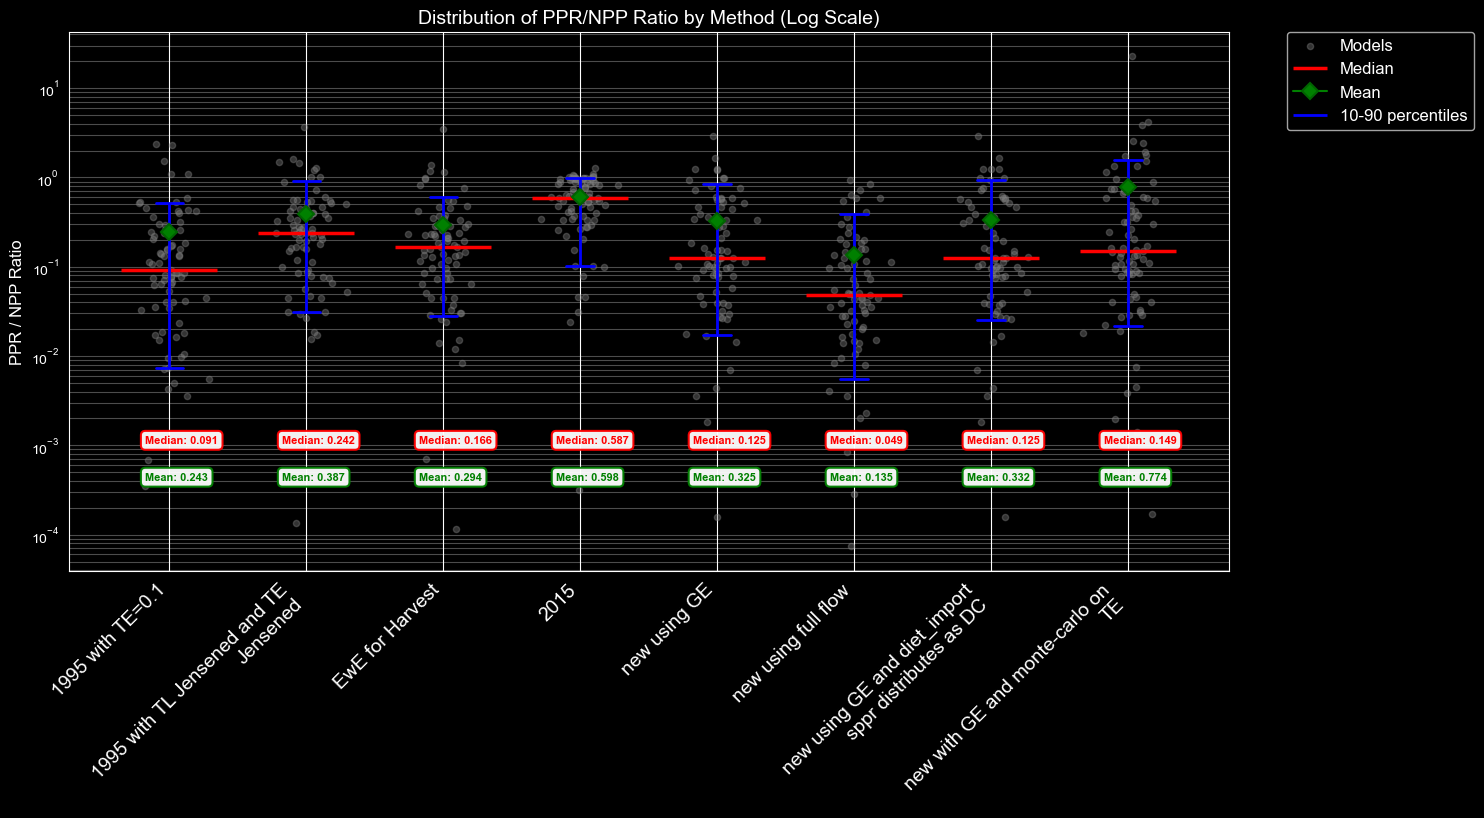

In [15]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7))

# Jitter width for horizontal spread
jitter_width = 0.1

methods = PPR2NPP_inner.columns
# methods = PPR2NPP_all.columns
x_positions = np.arange(len(methods))

# Plot for each method
for i, sppr_method in enumerate(methods):
    method = renaming_dict[sppr_method]
    good_models = df_checks.all(axis=1) & df_sppr_not_explode[sppr_method]
    print(f'{method}: {(~good_models).sum()}')
    data = PPR2NPP_inner.loc[good_models, sppr_method].dropna().values
    data = data[data > 0]
    # data = PPR2NPP_inner[sppr_method].dropna().values
    
    # Skip if no data
    if len(data) == 0:
        continue
    
    # Add jittered points (smaller and single color)
    jitter = np.random.normal(0, jitter_width, size=len(data))
    ax.scatter(x_positions[i] + jitter, data, alpha=0.4, s=20, color='gray', label='Models' if i == 0 else '')
    
    # Calculate statistics
    median_val = np.median(data)
    mean_val = np.mean(data)
    p10 = np.percentile(data, 10)
    p90 = np.percentile(data, 90)
    
    # Plot median line
    ax.hlines(median_val, x_positions[i] - 0.35, x_positions[i] + 0.35, 
             colors='red', linestyles='solid', linewidth=2.5, label='Median' if i == 0 else '')
    
    # Add median value annotation (positioned right and above)
    ax.annotate(f'Median: {median_val:.3f}', xy=(x_positions[i]-0.175, 1e-3),
                xytext=(0, 0), textcoords='offset points',
                fontsize=8, color='red', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='red', linewidth=1.5),
                ha='left', va='bottom',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
    
    # Plot mean marker
    if np.isfinite(mean_val):
        ax.plot(x_positions[i], mean_val, marker='D', markersize=8, color='green', 
               markeredgecolor='darkgreen', markeredgewidth=1.5, label='Mean' if i == 0 else '', zorder=3)
        
        # Add mean value annotation (positioned right and below)
        ax.annotate(f'Mean: {mean_val:.3f}', xy=(x_positions[i]-0.175, 1e-3/2),
                    xytext=(0, 0), textcoords='offset points',
                    fontsize=8, color='green', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='green', linewidth=1.5),
                    ha='left', va='top',
                    arrowprops=dict(arrowstyle='->', color='green', lw=0.5))
    
    # Plot whiskers (10th and 90th percentiles)
    ax.vlines(x_positions[i], p10, p90, colors='blue', linewidth=2, label='10-90 percentiles' if i == 0 else '')
    ax.plot([x_positions[i] - 0.1, x_positions[i] + 0.1], [p10, p10], 'b-', linewidth=2)
    ax.plot([x_positions[i] - 0.1, x_positions[i] + 0.1], [p90, p90], 'b-', linewidth=2)

ax.set_xticks(x_positions)
labels = ["\n".join(textwrap.wrap(str(label), width=30)) for label in renaming_dict.values()]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=14)
ax.set_ylabel('PPR / NPP Ratio', fontsize=12)
ax.set_title('Distribution of PPR/NPP Ratio by Method (Log Scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=12, bbox_to_anchor=(1.05, 1), borderaxespad=0, frameon=True)
ax.grid(True, alpha=0.3, axis='y', which='both')
plt.subplots_adjust(right=0.85)
plt.show()

In [ ]:
19/3 * 5/110 + 5/110 + 100/110